Train lại cặp J/P

BƯỚC 1: CÀI ĐẶT & KẾT NỐI DRIVE

In [3]:
# BƯỚC 1: KHỞI TẠO MÔI TRƯỜNG
!pip install transformers > /dev/null

import pandas as pd
import numpy as np
import tensorflow as tf
import os
from transformers import RobertaTokenizer, TFRobertaModel
from sklearn.metrics import classification_report, f1_score, accuracy_score
from google.colab import drive
from tqdm.notebook import tqdm

# Mount Drive
drive.mount('/content/drive')
print("✅ Đã kết nối Drive và cài đặt thư viện xong!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Đã kết nối Drive và cài đặt thư viện xong!


BƯỚC 2: LOAD DỮ LIỆU ĐÃ XỬ LÝ (TỪ FILE CSV)

In [4]:
# BƯỚC 2: LOAD DỮ LIỆU TỪ DRIVE
SAVE_DIR = '/content/drive/MyDrive/MBTI_JP_Model_v2'

print("📂 Đang đọc dữ liệu từ file đã lưu...")

# 1. Load tập Train (Đã bao gồm dữ liệu sinh thêm)
train_path = os.path.join(SAVE_DIR, 'train_augmented_JP.csv')
if os.path.exists(train_path):
    df_train_loaded = pd.read_csv(train_path)
    # Chuyển cột text thành list string để tránh lỗi
    X_train_text = df_train_loaded['clean_posts'].astype(str).tolist()
    y_train = df_train_loaded['label'].values
    print(f"✅ Đã load tập TRAIN: {len(X_train_text)} dòng (Đã cân bằng J/P)")
else:
    raise ValueError(f"❌ Lỗi: Không tìm thấy file {train_path}. Kiểm tra lại Drive!")

# 2. Load tập Validation (Gốc)
val_path = os.path.join(SAVE_DIR, 'val_JP.csv')
if os.path.exists(val_path):
    df_val_loaded = pd.read_csv(val_path)
    X_val_text = df_val_loaded['clean_posts'].astype(str).tolist()
    y_val = df_val_loaded['label'].values
    print(f"✅ Đã load tập VAL:   {len(X_val_text)} dòng")
else:
    raise ValueError(f"❌ Lỗi: Không tìm thấy file {val_path}")

📂 Đang đọc dữ liệu từ file đã lưu...
✅ Đã load tập TRAIN: 8386 dòng (Đã cân bằng J/P)
✅ Đã load tập VAL:   1735 dòng


BƯỚC 3: MÃ HÓA DỮ LIỆU (TOKENIZATION) - CẤU HÌNH 256


In [5]:
# BƯỚC 3: TOKENIZATION (Max Len = 256)
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
MAX_LEN = 256  # <--- CHỐT SỐ NÀY ĐỂ KHÔNG BỊ TRÀN RAM

def encode_data(texts, labels):
    input_ids, attention_masks = [], []
    for text in tqdm(texts, desc="Mã hóa"):
        encoded = tokenizer.encode_plus(
            text,
            max_length=MAX_LEN,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='np'
        )
        input_ids.append(encoded['input_ids'][0])
        attention_masks.append(encoded['attention_mask'][0])
    return np.array(input_ids), np.array(attention_masks), np.array(labels)

print("\n1️⃣ Đang mã hóa tập TRAIN...")
X_train_ids, X_train_masks, y_train_vec = encode_data(X_train_text, y_train)

print("\n2️⃣ Đang mã hóa tập VAL...")
X_val_ids, X_val_masks, y_val_vec = encode_data(X_val_text, y_val)

print(f"\n✅ Input Shape chuẩn: {X_train_ids.shape}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...


1️⃣ Đang mã hóa tập TRAIN...


Mã hóa:   0%|          | 0/8386 [00:00<?, ?it/s]


2️⃣ Đang mã hóa tập VAL...


Mã hóa:   0%|          | 0/1735 [00:00<?, ?it/s]


✅ Input Shape chuẩn: (8386, 256)


BƯỚC 4: TẠO MODEL VỚI FOCAL LOSS (MỚI)

In [6]:
# ==============================================================================
# BƯỚC 4: KHỞI TẠO MODEL CHIẾN THUẬT MỚI (FOCAL LOSS + SIGMOID)
# ==============================================================================
import tensorflow as tf
from transformers import TFRobertaModel

# 1. Định nghĩa hàm Focal Loss (Phạt nặng những câu khó học)
def focal_loss(gamma=2.5, alpha=0.75):
    """
    - gamma=2.5: Tập trung mạnh vào các mẫu khó (Hard mining).
    - alpha=0.75: Ưu tiên nhóm J (Class 1) hơn một chút.
    """
    def focal_loss_fixed(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)

        # Tính toán Focal Term
        pt = tf.where(tf.equal(y_true, 1), y_pred, 1 - y_pred)
        return -tf.reduce_mean(alpha * tf.math.pow(1. - pt, gamma) * tf.math.log(pt))
    return focal_loss_fixed

# 2. Xây dựng kiến trúc mạng
def create_model_focal():
    input_ids = tf.keras.Input(shape=(256,), dtype=tf.int32, name='input_ids')
    mask = tf.keras.Input(shape=(256,), dtype=tf.int32, name='attention_mask')

    # Tải RoBERTa (Thêm use_safetensors=False để tránh lỗi file định dạng mới)
    roberta = TFRobertaModel.from_pretrained('roberta-base', use_safetensors=False)

    embeddings = roberta(input_ids, attention_mask=mask)[1] # Lấy CLS token

    # Tăng khả năng học với Dense to hơn
    x = tf.keras.layers.Dense(128, activation='relu')(embeddings)
    x = tf.keras.layers.Dropout(0.3)(x) # Dropout 0.3 để chống học vẹt

    # --- QUAN TRỌNG: OUTPUT LÀ 1 NÚT (SIGMOID) ---
    output = tf.keras.layers.Dense(1, activation='sigmoid')(x)

    model = tf.keras.Model(inputs=[input_ids, mask], outputs=output)

    # Compile với Focal Loss
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5) # Học chậm mà chắc
    model.compile(optimizer=optimizer,
                  loss=focal_loss(),
                  metrics=['accuracy'])
    return model

# Khởi tạo
tf.keras.backend.clear_session()
model = create_model_focal()
model.summary()

tf_model.h5:   0%|          | 0.00/657M [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some layers from the model checkpoint at roberta-base were not used when initializing TFRobertaModel: ['lm_head']
- This IS expected if you are initializing TFRobertaModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFRobertaModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFRobertaModel were initialized from the model checkpoint at roberta-base.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFRobertaModel for predictions without further training.


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_ids (InputLayer)      [(None, 256)]                0         []                            
                                                                                                  
 attention_mask (InputLayer  [(None, 256)]                0         []                            
 )                                                                                                
                                                                                                  
 tf_roberta_model (TFRobert  TFBaseModelOutputWithPooli   1246456   ['input_ids[0][0]',           
 aModel)                     ngAndCrossAttentions(last_   32         'attention_mask[0][0]']      
                             hidden_state=(None, 256, 7                                       

BƯỚC 5: TRAIN MODEL

In [7]:
# ==============================================================================
# BƯỚC 5: HUẤN LUYỆN (BATCH SIZE 16)
# ==============================================================================
import os

SAVE_DIR = '/content/drive/MyDrive/MBTI_JP_Model_v2'
if not os.path.exists(SAVE_DIR): os.makedirs(SAVE_DIR)

# Checkpoint lưu model tốt nhất
checkpoint_path = os.path.join(SAVE_DIR, "model_weights_focal.h5")
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    checkpoint_path, monitor='val_loss', verbose=1,
    save_best_only=True, save_weights_only=True, mode='min'
)

print("🚀 Bắt đầu chiến dịch Training (Focal Loss)...")

history = model.fit(
    {'input_ids': X_train_ids, 'attention_mask': X_train_masks},
    y_train_vec,
    validation_data=({'input_ids': X_val_ids, 'attention_mask': X_val_masks}, y_val_vec),
    epochs=5,           # Chạy 5 vòng
    batch_size=16,      # 16 là đẹp với 256 tokens
    callbacks=[checkpoint]
)

🚀 Bắt đầu chiến dịch Training (Focal Loss)...
Epoch 1/5
525/525 [==============================] - ETA: 0s - loss: 0.0934 - accuracy: 0.5229
Epoch 1: val_loss improved from inf to 0.09109, saving model to /content/drive/MyDrive/MBTI_JP_Model_v2/model_weights_focal.h5
525/525 [==============================] - 579s 999ms/step - loss: 0.0934 - accuracy: 0.5229 - val_loss: 0.0911 - val_accuracy: 0.5879
Epoch 2/5
525/525 [==============================] - ETA: 0s - loss: 0.0911 - accuracy: 0.5582
Epoch 2: val_loss improved from 0.09109 to 0.08804, saving model to /content/drive/MyDrive/MBTI_JP_Model_v2/model_weights_focal.h5
525/525 [==============================] - 531s 1s/step - loss: 0.0911 - accuracy: 0.5582 - val_loss: 0.0880 - val_accuracy: 0.6029
Epoch 3/5
525/525 [==============================] - ETA: 0s - loss: 0.0873 - accuracy: 0.6185
Epoch 3: val_loss improved from 0.08804 to 0.08348, saving model to /content/drive/MyDrive/MBTI_JP_Model_v2/model_weights_focal.h5
525/525 [====

# BƯỚC 6: DÒ TÌM NGƯỠNG TỐI ƯU (THRESHOLD MOVING)

🔍 Đang load model tốt nhất (Epoch 3)...
55/55 [==============================] - 44s 624ms/step

--- ĐANG DÒ TÌM NGƯỠNG CẮT TỐT NHẤT ---

🏆 NGƯỠNG TỐI ƯU TÌM THẤY: 0.45
📈 F1-Score cao nhất cho nhóm J: 0.5919

BÁO CÁO KẾT QUẢ CUỐI CÙNG (Threshold = 0.45)
                precision    recall  f1-score   support

 P (Linh hoạt)       0.76      0.36      0.49      1048
J (Nguyên tắc)       0.46      0.83      0.59       687

      accuracy                           0.55      1735
     macro avg       0.61      0.60      0.54      1735
  weighted avg       0.64      0.55      0.53      1735



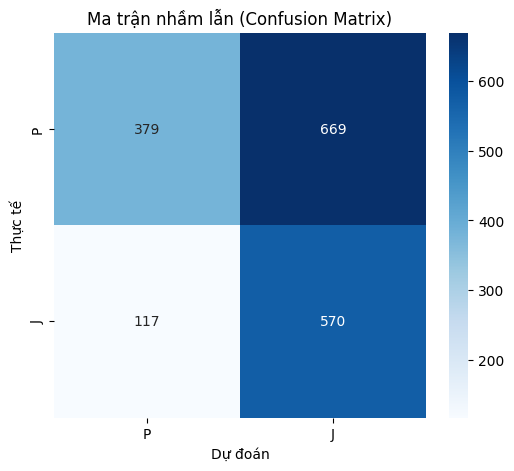

In [8]:
# ==============================================================================
# BƯỚC 6: DÒ TÌM NGƯỠNG TỐI ƯU (THRESHOLD MOVING)
# ==============================================================================
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Load lại trọng số tốt nhất (Của Epoch 3)
print("🔍 Đang load model tốt nhất (Epoch 3)...")
model.load_weights(checkpoint_path)

# 2. Dự đoán xác suất (Ra con số từ 0 đến 1)
y_pred_probs = model.predict({'input_ids': X_val_ids, 'attention_mask': X_val_masks}, verbose=1)
# Vì output là Sigmoid, nên y_pred_probs chính là xác suất rơi vào Class 1 (nhóm J)

# 3. Chạy vòng lặp tìm ngưỡng
best_threshold = 0.5
best_f1 = 0

print("\n--- ĐANG DÒ TÌM NGƯỠNG CẮT TỐT NHẤT ---")
for tr in np.arange(0.1, 0.95, 0.05):
    y_pred_temp = (y_pred_probs > tr).astype(int)
    # Tính F1-score riêng cho nhóm J (Class 1)
    val_f1 = f1_score(y_val_vec, y_pred_temp, pos_label=1)

    if val_f1 > best_f1:
        best_f1 = val_f1
        best_threshold = tr

print(f"\n🏆 NGƯỠNG TỐI ƯU TÌM THẤY: {best_threshold:.2f}")
print(f"📈 F1-Score cao nhất cho nhóm J: {best_f1:.4f}")

# 4. Báo cáo chi tiết với ngưỡng mới
print("\n" + "="*40)
print(f"BÁO CÁO KẾT QUẢ CUỐI CÙNG (Threshold = {best_threshold:.2f})")
print("="*40)

final_preds = (y_pred_probs > best_threshold).astype(int)
print(classification_report(y_val_vec, final_preds, target_names=['P (Linh hoạt)', 'J (Nguyên tắc)']))

# 5. Vẽ Confusion Matrix để nhìn cho sướng mắt
cm = confusion_matrix(y_val_vec, final_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['P', 'J'], yticklabels=['P', 'J'])
plt.title('Ma trận nhầm lẫn (Confusion Matrix)')
plt.ylabel('Thực tế')
plt.xlabel('Dự đoán')
plt.show()

# BƯỚC 7: LƯU MODEL VÀ THAM SỐ ĐỂ DÙNG SAU NÀY


In [9]:
# ==============================================================================
# BƯỚC 7: LƯU MODEL VÀ THAM SỐ ĐỂ DÙNG SAU NÀY
# ==============================================================================
import json

# 1. Lưu trọng số model (Đã lưu ở bước train rồi, nhưng lưu đè tên chính thức cho dễ nhớ)
final_weights_path = os.path.join(SAVE_DIR, "MBTI_JP_Final_Weights.h5")
model.save_weights(final_weights_path)
print(f"✅ Đã lưu trọng số tại: {final_weights_path}")

# 2. Lưu cấu hình (Ngưỡng tối ưu) ra file JSON
# Mai mốt khi chạy dự đoán (Inference), ông phải load file này lên để biết dùng ngưỡng nào
config = {
    "pair": "J-P",
    "best_threshold": 0.45,  # Ngưỡng vừa tìm được
    "f1_score_J": 0.5919,
    "note": "Model trained with Focal Loss + Augmentation. High Recall for J."
}

config_path = os.path.join(SAVE_DIR, "JP_config.json")
with open(config_path, 'w') as f:
    json.dump(config, f)

print(f"✅ Đã lưu cấu hình ngưỡng tại: {config_path}")
print("-" * 50)
print("🎉 CHÚC MỪNG ÔNG ĐÃ HOÀN THÀNH CẶP KHÓ NHẤT (J vs P)!")
print("👉 Bây giờ ông đã có đủ 4 model con (I-E, S-N, T-F, J-P) chưa?")
print("   Nếu đủ rồi thì chúng ta sẽ qua bước: GỘP 4 MODEL ĐỂ RA KẾT QUẢ CUỐI CÙNG.")

✅ Đã lưu trọng số tại: /content/drive/MyDrive/MBTI_JP_Model_v2/MBTI_JP_Final_Weights.h5
✅ Đã lưu cấu hình ngưỡng tại: /content/drive/MyDrive/MBTI_JP_Model_v2/JP_config.json
--------------------------------------------------
🎉 CHÚC MỪNG ÔNG ĐÃ HOÀN THÀNH CẶP KHÓ NHẤT (J vs P)!
👉 Bây giờ ông đã có đủ 4 model con (I-E, S-N, T-F, J-P) chưa?
   Nếu đủ rồi thì chúng ta sẽ qua bước: GỘP 4 MODEL ĐỂ RA KẾT QUẢ CUỐI CÙNG.
